# Human Activity Recognition from Smartphone Sensors

**Goal:** recognise what a person is doing (walking, sitting, lying, ...) from the accelerometer and
gyroscope of a smartphone worn on the waist.

This is the same family of problems as **fall detection**: classify short windows of body-worn
inertial signals. The key challenge is to generalise to **new people**, not only new windows of the
same people.

**Dataset:** [UCI Human Activity Recognition Using Smartphones](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones)
- 30 volunteers, smartphone on the waist, signals sampled at 50 Hz
- Signals cut into windows of 2.56 s (128 samples) with 50% overlap
- 561 hand-crafted features per window (time and frequency domain)
- 6 activities; official split by person: 21 subjects for training, 9 different subjects for testing

**Outline:** 1. Data · 2. Feature structure · 3. Visualisation · 4. Why we must split by subject ·
5. Model comparison · 6. Curse of dimensionality and PCA · 7. Hyperparameter tuning ·
8. Test results · 9. Error analysis · 10. Which sensors matter · 11. Conclusions

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))  # make src/ importable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from src import config
from src.data import download_data, feature_group, load_dataset
from src.dimensionality import distance_contrast
from src.evaluation import (compare_models, evaluate, group_permutation_importance,
                            per_subject_accuracy, plot_confusion_matrix)
from src.models import build_models, with_pca

config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.dpi"] = 100
ACTIVITIES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]
COLORS = dict(zip(ACTIVITIES, ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]))

# Subject-level cross-validation: all windows of one person stay in the same fold
GROUP_CV = StratifiedGroupKFold(n_splits=config.CV_FOLDS, shuffle=True, random_state=config.RANDOM_STATE)


def save(fig, name):
    fig.savefig(config.FIGURES_DIR / name, dpi=150, bbox_inches="tight")

## 1. Load the data

In [2]:
download_data()
(X_train, y_train, subj_train), (X_test, y_test, subj_test) = load_dataset()

print(f"Train: {X_train.shape[0]:,} windows, {X_train.shape[1]} features, {subj_train.nunique()} subjects")
print(f"Test:  {X_test.shape[0]:,} windows, {subj_test.nunique()} subjects")
print("Subject overlap between train and test:", set(subj_train) & set(subj_test) or "none")
print(f"Missing values: {X_train.isna().sum().sum()}")
X_train.iloc[:5, :8]

Data already exists: data/raw


Train: 7,352 windows, 561 features, 21 subjects
Test:  2,947 windows, 9 subjects
Subject overlap between train and test: none
Missing values: 0


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672


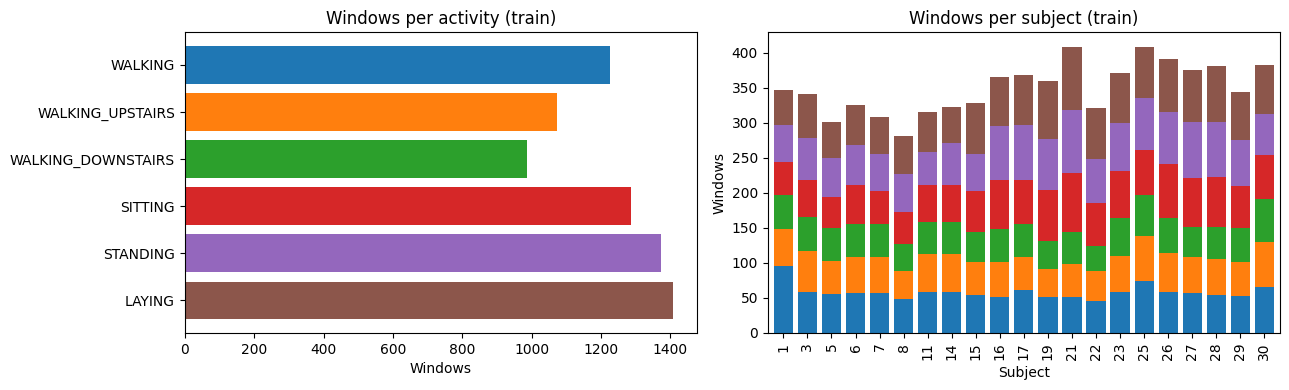

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = y_train.value_counts().reindex(ACTIVITIES)
axes[0].barh(counts.index, counts.values, color=[COLORS[a] for a in counts.index])
axes[0].invert_yaxis()
axes[0].set(title="Windows per activity (train)", xlabel="Windows")

pd.crosstab(subj_train, y_train)[ACTIVITIES].plot.bar(
    stacked=True, ax=axes[1], color=[COLORS[a] for a in ACTIVITIES], width=0.8, legend=False)
axes[1].set(title="Windows per subject (train)", xlabel="Subject", ylabel="Windows")
fig.tight_layout()
save(fig, "class_distribution.png")
plt.show()

**Observations:**
- The classes are fairly **balanced** (986 to 1,407 windows per activity), so accuracy is meaningful, but we
  still report macro-F1 to treat every activity equally.
- Each subject has about 280–410 windows of all six activities. Every person appears many times, which is
  important for section 4.
- The official split is by person: the 9 test subjects never appear in training. No missing values.

## 2. Feature structure

The 561 features were computed by the dataset authors from the raw signals: means, standard deviations,
energy, entropy, FFT band energies, correlations, angles, and more. The name prefix tells us the signal:
`t` = time domain, `f` = frequency domain (FFT); `BodyAcc` / `GravityAcc` = accelerometer split into body
movement and gravity; `Gyro` = gyroscope; `Jerk` = derivative (rate of change); `Mag` = magnitude of the 3 axes.

In [4]:
groups = pd.Series(X_train.columns).map(feature_group)
FEATURE_GROUPS = {g: X_train.columns[groups == g].tolist() for g in groups.unique()}
print(f"{len(FEATURE_GROUPS)} signal groups")
groups.value_counts().rename("n_features").to_frame().T

18 signal groups


,fBodyAcc,fBodyAccJerk,fBodyGyro,tBodyAcc,tGravityAcc,tBodyAccJerk,tBodyGyro,tBodyGyroJerk,tBodyAccMag,tGravityAccMag,tBodyAccJerkMag,tBodyGyroMag,tBodyGyroJerkMag,fBodyAccMag,fBodyBodyAccJerkMag,fBodyBodyGyroMag,fBodyBodyGyroJerkMag,angle
n_features,79,79,79,40,40,40,40,40,13,13,13,13,13,13,13,13,13,7


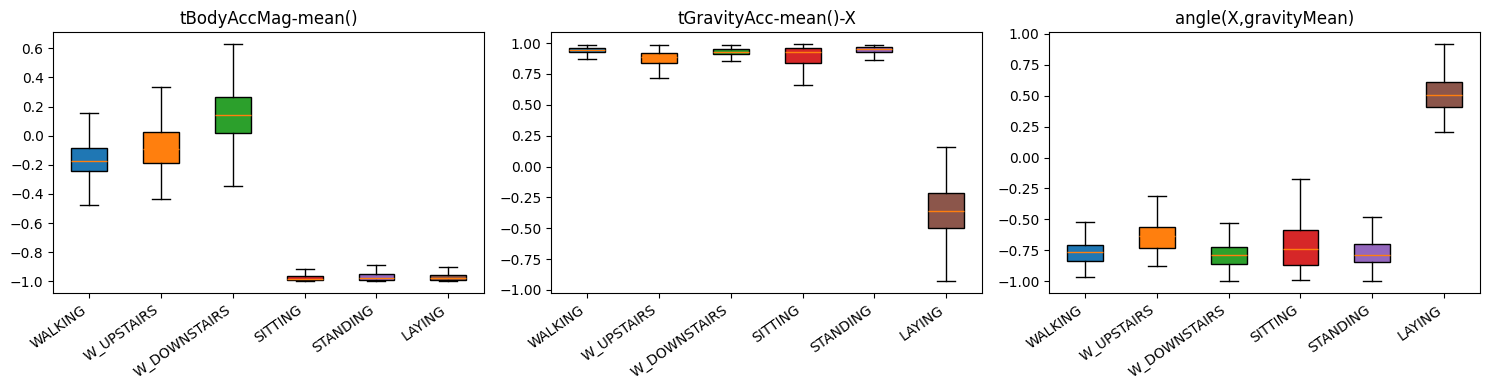

In [5]:
examples = ["tBodyAccMag-mean()", "tGravityAcc-mean()-X", "angle(X,gravityMean)"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feature in zip(axes, examples):
    data = [X_train.loc[y_train == a, feature] for a in ACTIVITIES]
    box = ax.boxplot(data, patch_artist=True, showfliers=False)
    for patch, activity in zip(box["boxes"], ACTIVITIES):
        patch.set_facecolor(COLORS[activity])
    ax.set_xticks(range(1, 7), [a.replace("WALKING_", "W_") for a in ACTIVITIES], rotation=35, ha="right")
    ax.set_title(feature)
fig.tight_layout()
save(fig, "example_features.png")
plt.show()

**Observations:**
- `tBodyAccMag-mean()` (how much the body moves) separates **dynamic** activities (walking) from **static**
  ones (sitting, standing, lying) almost perfectly.
- `tGravityAcc-mean()-X` and `angle(X,gravityMean)` describe the **orientation** of the phone relative to
  gravity. They separate **lying** clearly, because the body is horizontal.
- Sitting and standing look very similar in all three features: both are static and upright. We expect
  most errors there.

## 3. Visualising 561 dimensions in 2D

- **PCA** (linear): projects onto the directions of largest variance.
- **t-SNE** (non-linear): keeps close points close. Good for seeing clusters, but distances between
  clusters are not meaningful. We run it on the first 50 PCA components (standard practice, faster and less noisy).

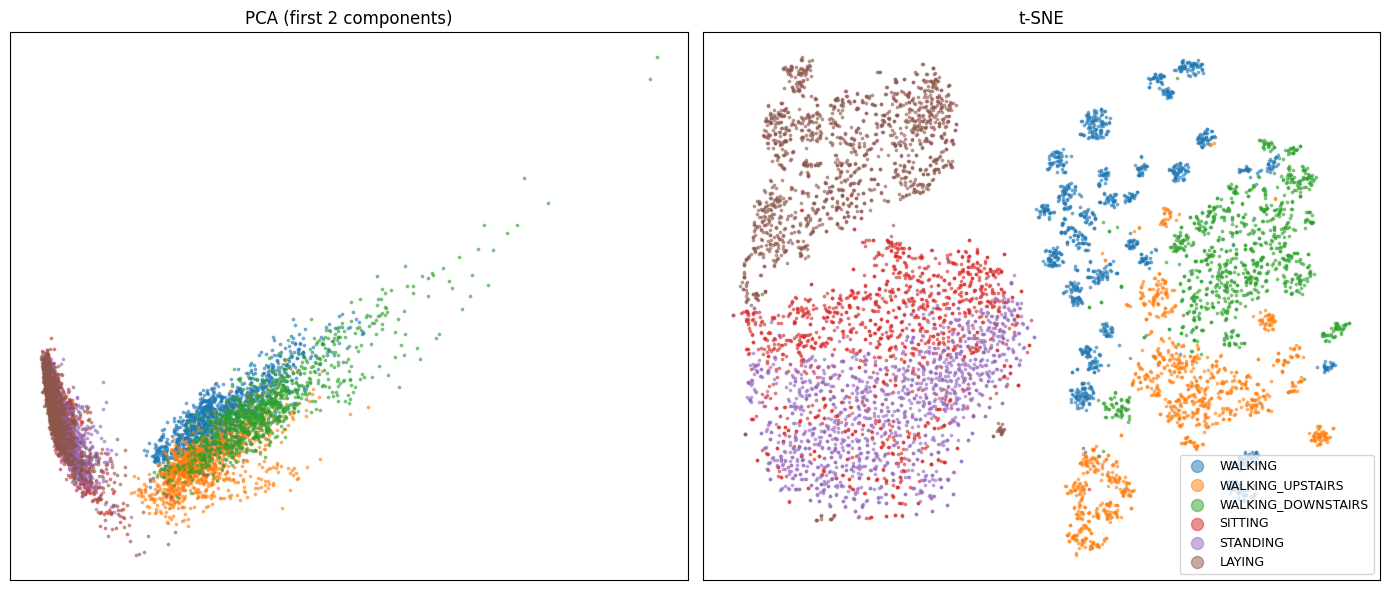

In [6]:
X_train_scaled = StandardScaler().fit_transform(X_train)
pca_50 = PCA(n_components=50, random_state=config.RANDOM_STATE).fit_transform(X_train_scaled)
tsne_2d = TSNE(n_components=2, perplexity=40, random_state=config.RANDOM_STATE).fit_transform(pca_50)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, points, title in [(axes[0], pca_50[:, :2], "PCA (first 2 components)"),
                          (axes[1], tsne_2d, "t-SNE")]:
    for activity in ACTIVITIES:
        mask = (y_train == activity).to_numpy()
        ax.scatter(points[mask, 0], points[mask, 1], s=3, alpha=0.5, color=COLORS[activity], label=activity)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(markerscale=5, loc="best", fontsize=9)
fig.tight_layout()
save(fig, "pca_tsne.png")
plt.show()

**Observations:**
- Both views show a clear **two-level structure**: dynamic activities (walking types) and static
  activities (sitting, standing, lying) are far apart.
- In t-SNE, lying forms its own cluster, and the three walking types are mostly separated. **Sitting and
  standing overlap heavily**, confirming what we saw in the features.
- t-SNE also shows many small sub-clusters inside each activity. These are often **individual subjects**:
  each person moves in a slightly different way. This is why the split by subject matters (next section).

## 4. Why we must split by subject

Two properties of this data make a random split dangerous:
1. **Same person on both sides:** the model can learn the personal "movement style" of each subject.
2. **Overlapping windows:** windows overlap by 50%, so neighbouring windows share half of their raw signal.
   A random split puts almost identical windows in train and validation.

We compare random 5-fold CV with subject-level 5-fold CV (`StratifiedGroupKFold`) on the training set.

In [7]:
leak_models = {name: build_models()[name] for name in ["knn", "rbf_svm", "random_forest"]}
random_cv = StratifiedKFold(n_splits=config.CV_FOLDS, shuffle=True, random_state=config.RANDOM_STATE)

random_scores = compare_models(leak_models, X_train, y_train, cv=random_cv).set_index("model")
subject_scores = compare_models(leak_models, X_train, y_train, cv=GROUP_CV, groups=subj_train).set_index("model")

leakage = pd.DataFrame({
    "random split (leaky)": random_scores["accuracy_mean"],
    "subject split (honest)": subject_scores["accuracy_mean"],
})
leakage["optimism (pp)"] = (leakage.iloc[:, 0] - leakage.iloc[:, 1]) * 100
leakage.round(4)

,random split (leaky),subject split (honest),optimism (pp)
model,,,
rbf_svm,0.9876,0.9313,5.6273
random_forest,0.9823,0.9075,7.4834
knn,0.9597,0.8774,8.2357


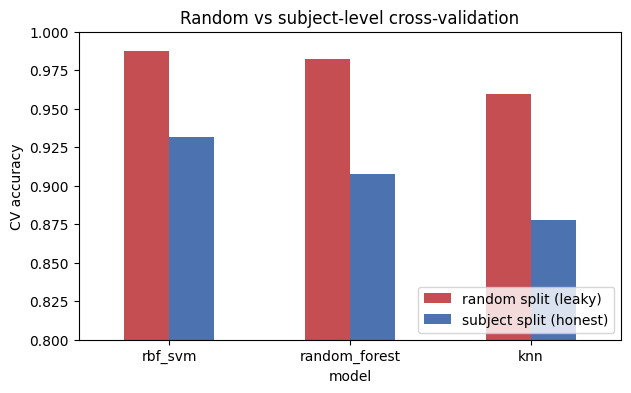

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
leakage.iloc[:, :2].plot.bar(ax=ax, rot=0, color=["#c44e52", "#4c72b0"])
ax.set(ylim=(0.8, 1.0), ylabel="CV accuracy", title="Random vs subject-level cross-validation")
ax.legend(loc="lower right")
save(fig, "leakage_random_vs_subject.png")
plt.show()

**Result: a random split overestimates accuracy by 5.6 to 8.2 percentage points.**

| Model | Random split | Subject split | Optimism |
|---|---|---|---|
| RBF SVM | 98.8% | 93.1% | 5.6 pp |
| Random Forest | 98.2% | 90.8% | 7.5 pp |
| kNN | 96.0% | 87.7% | 8.2 pp |

With a random split, the model is partly tested on windows that overlap with training windows of the same
person. kNN is affected most, because it can simply find the neighbouring window of the same subject.

**Lesson (also true for fall detection and medical imaging):** the evaluation split must match the real use
case. The model will be used on **new people**, so it must be validated on new people. From here on, every
evaluation uses subject-level CV.

## 5. Model comparison (subject-level 5-fold CV)

Six classic models, from simple to complex. Metric: **macro-F1** (average F1 over the 6 classes, so every
activity counts equally). All preprocessing is inside the pipelines.

In [9]:
cv_results = compare_models(build_models(), X_train, y_train, cv=GROUP_CV, groups=subj_train)
cv_results.to_csv(config.REPORTS_DIR / "cv_results.csv", index=False)
cv_results.round(4)

,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,fit_time_s
0,linear_svm,0.9400,0.0334,0.9385,0.0347,0.5852
1,logistic_regression,0.9359,0.0345,0.9351,0.0340,0.8792
2,rbf_svm,0.9313,0.0247,0.9295,0.0251,1.0713
3,hist_gradient_boosting,0.9262,0.0391,0.9237,0.0420,21.9737
4,random_forest,0.9075,0.0485,0.9031,0.0529,21.8862
5,knn,0.8774,0.0266,0.8749,0.0258,0.0821


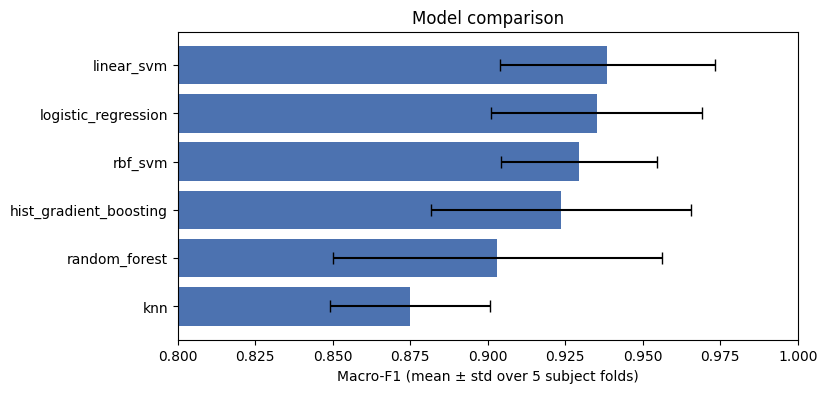

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
order = cv_results.sort_values("macro_f1_mean")
ax.barh(order["model"], order["macro_f1_mean"], xerr=order["macro_f1_std"], capsize=4, color="#4c72b0")
ax.set(xlim=(0.8, 1.0), xlabel="Macro-F1 (mean ± std over 5 subject folds)", title="Model comparison")
save(fig, "model_comparison.png")
plt.show()

**Result: simple linear models are the best here.**
- Linear SVM (0.939) and logistic regression (0.935) are slightly better than RBF SVM (0.930) and gradient
  boosting (0.924), and they train **20–40× faster** than the tree ensembles.
- The differences between the top four models are **smaller than the fold-to-fold standard deviation**
  (±0.03), so they perform similarly. The standard deviation is large because some subjects are harder than others.
- **Why do linear models work so well?** The 561 features were carefully engineered by experts, so the
  classes are already almost linearly separable. More flexible models mainly learn extra patterns that are
  specific to the training subjects and do not transfer to new people.

## 6. Curse of dimensionality and PCA

### 6.1 Distances lose meaning in high dimensions
For random points, we measure the contrast between the farthest and the nearest pair:
(max − min) / min. When it goes towards 0, all points are almost equally far apart.

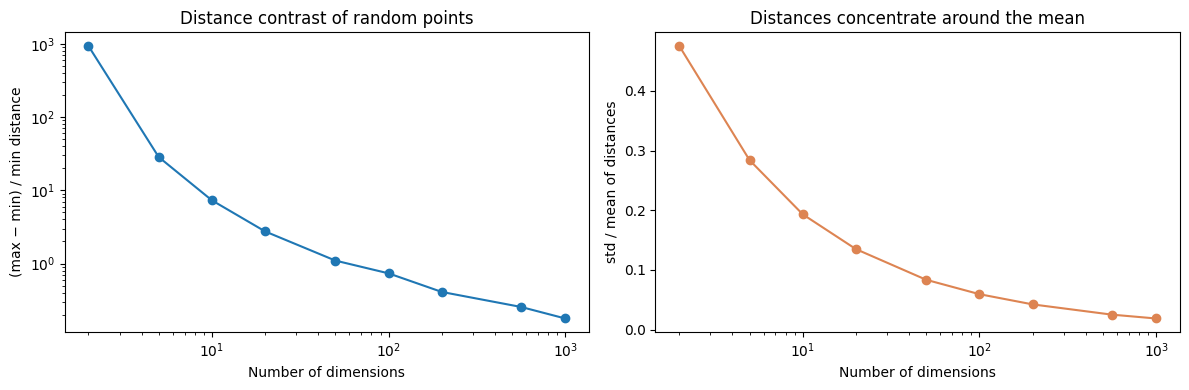

,dimensions,contrast,mean_distance,std_over_mean
0,2,934.624,0.527,0.475
1,5,28.403,0.884,0.284
2,10,7.284,1.259,0.193
3,20,2.743,1.811,0.135
4,50,1.096,2.882,0.083
5,100,0.733,4.065,0.059
6,200,0.409,5.776,0.042
7,561,0.255,9.661,0.025
8,1000,0.177,12.904,0.018


In [11]:
contrast = distance_contrast([2, 5, 10, 20, 50, 100, 200, 561, 1000], n_points=500,
                             random_state=config.RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(contrast["dimensions"], contrast["contrast"], marker="o")
axes[0].set(xscale="log", yscale="log", xlabel="Number of dimensions",
            ylabel="(max − min) / min distance", title="Distance contrast of random points")
axes[1].plot(contrast["dimensions"], contrast["std_over_mean"], marker="o", color="#dd8452")
axes[1].set(xscale="log", xlabel="Number of dimensions", ylabel="std / mean of distances",
            title="Distances concentrate around the mean")
fig.tight_layout()
save(fig, "distance_concentration.png")
plt.show()
contrast.round(3)

**Result:** with 2 dimensions, the farthest pair of points is ~935× farther than the nearest pair.
With 561 dimensions (our feature count) this ratio falls to **0.26**: all points are at almost the same
distance from each other. The relative spread of distances (std / mean) drops from 0.48 to 0.025.

This is the **curse of dimensionality**: in high dimensions, the idea of a "nearest" neighbour becomes weak,
and methods that rely on distances (kNN, clustering) can fail. This happens for **random, independent**
dimensions. Real data is often different, as the next section shows.

### 6.2 How many dimensions does the real data need?
The 561 features are strongly correlated (e.g. the same statistic on X, Y and Z axes, or in time and
frequency domain), so the real information lives in far fewer dimensions.

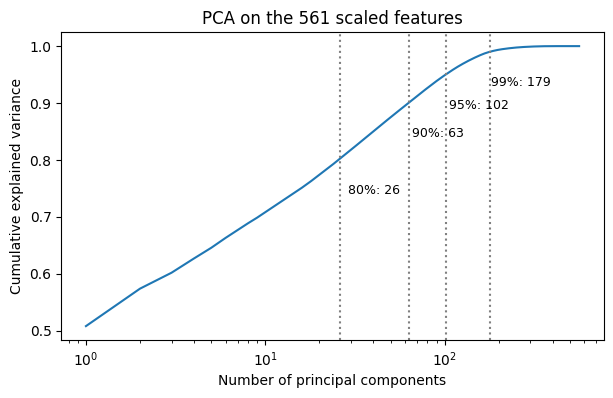

Components needed: {0.8: 26, 0.9: 63, 0.95: 102, 0.99: 179}


In [12]:
pca_full = PCA(random_state=config.RANDOM_STATE).fit(X_train_scaled)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
needed = {level: int(np.searchsorted(cumulative, level) + 1) for level in [0.80, 0.90, 0.95, 0.99]}

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(cumulative) + 1), cumulative)
for level, n in needed.items():
    ax.axvline(n, linestyle=":", color="gray")
    ax.text(n + 3, level - 0.06, f"{level:.0%}: {n}", fontsize=9)
ax.set(xscale="log", xlabel="Number of principal components", ylabel="Cumulative explained variance",
       title="PCA on the 561 scaled features")
save(fig, "pca_explained_variance.png")
plt.show()
print("Components needed:", needed)

### 6.3 Model performance vs number of PCA components
kNN depends only on distances, so it should suffer most from irrelevant dimensions.
We compare it with the linear SVM (the best model from section 5).

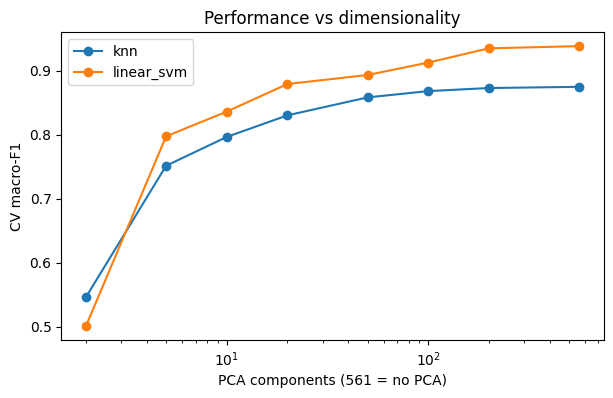

model,knn,linear_svm
components,,
2,0.5460,0.5007
5,0.7514,0.7975
10,0.7965,0.8361
20,0.8303,0.8792
50,0.8583,0.8933
100,0.8681,0.9128
200,0.8730,0.9350
561,0.8749,0.9385


In [13]:
component_grid = [2, 5, 10, 20, 50, 100, 200, 561]
rows = []
for base in ["knn", "linear_svm"]:
    for n in component_grid:
        model = build_models()[base] if n == X_train.shape[1] else with_pca(build_models()[base], n)
        score = compare_models({base: model}, X_train, y_train, cv=GROUP_CV, groups=subj_train)
        rows.append({"model": base, "components": n, "macro_f1": score["macro_f1_mean"].iloc[0]})
pca_curve = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4))
for base, frame in pca_curve.groupby("model"):
    ax.plot(frame["components"], frame["macro_f1"], marker="o", label=base)
ax.set(xscale="log", xlabel="PCA components (561 = no PCA)", ylabel="CV macro-F1",
       title="Performance vs dimensionality")
ax.legend()
save(fig, "pca_performance_curve.png")
plt.show()
pca_curve.pivot(index="components", columns="model", values="macro_f1").round(4)

**Results:**
- The 561 features are highly redundant: **26 components** keep 80% of the variance and **102** keep 95%.
  The real data lives in a much lower-dimensional space than 561.
- **kNN did not get worse** with more dimensions: it improves up to ~100 components and then stays flat
  (0.868 → 0.875). The extra 460 dimensions add almost no information, but they also do not destroy the
  distances. This is because they are **correlated** with the first components, not random noise as in 6.1.
  The **intrinsic dimension** of the data is low, so the curse is mild here.
- The **linear SVM keeps improving** up to all 561 features: the small-variance directions still contain
  useful signal for separating classes. PCA keeps variance, not class information, so it can drop useful details.
- **Conclusion:** PCA to ~100 components would make kNN 5× cheaper with no loss, but for the best model we
  keep all features.

## 7. Hyperparameter tuning

We tune the two best models from section 5. The regularisation parameter `C` controls the
bias-variance trade-off: small `C` = strong regularisation (simpler model), large `C` = weak regularisation.
The search uses the same subject-level CV, so the chosen `C` is the one that generalises best to **new people**.

In [14]:
search_space = {
    "linear_svm": {"model__C": [0.001, 0.01, 0.1, 1]},
    "logistic_regression": {"model__C": [0.01, 0.1, 1, 10]},
}
searches = {}
for name, grid in search_space.items():
    search = GridSearchCV(build_models()[name], grid, cv=GROUP_CV, scoring="f1_macro", n_jobs=-1)
    search.fit(X_train, y_train, groups=subj_train)
    searches[name] = search
    print(f"{name:20s} best {search.best_params_}  CV macro-F1 = {search.best_score_:.4f}")

pd.concat({
    name: pd.DataFrame(s.cv_results_)[["param_model__C", "mean_test_score", "std_test_score"]]
    for name, s in searches.items()
}).round(4)

linear_svm           best {'model__C': 0.1}  CV macro-F1 = 0.9385


logistic_regression  best {'model__C': 1}  CV macro-F1 = 0.9351


param_model__C  mean_test_score  std_test_score
linear_svm          0           0.001           0.9277          0.0349
                    1           0.010           0.9330          0.0325
                    2           0.100           0.9385          0.0347
                    3           1.000           0.9369          0.0353
logistic_regression 0           0.010           0.9266          0.0386
                    1           0.100           0.9338          0.0345
                    2           1.000           0.9351          0.0340
                    3          10.000           0.9299          0.0288

In [15]:
best_name = max(searches, key=lambda name: searches[name].best_score_)
final_model = searches[best_name].best_estimator_
print(f"Final model: {best_name} with {searches[best_name].best_params_}")

Final model: linear_svm with {'model__C': 0.1}


**Result:** the best values are `C = 0.1` for the linear SVM and `C = 1` for logistic regression, which are
the default values we used in section 5. Performance is quite flat around the optimum: very strong
regularisation (small `C`) underfits a little, and weak regularisation (large `C` for logistic regression)
starts to overfit to the training subjects. The **linear SVM with C = 0.1** is the final model.

## 8. Test results on 9 new subjects

The test subjects were not used for model selection or tuning.

In [16]:
result = evaluate(final_model, X_train, y_train, X_test, y_test)
y_pred = result["y_pred"]
print(f"Test accuracy: {result['accuracy']:.4f}")
print(f"Test macro-F1: {result['macro_f1']:.4f}\n")
report = classification_report(y_test, y_pred, labels=ACTIVITIES, digits=3, output_dict=True)
pd.DataFrame(report).T.round(3).to_csv(config.REPORTS_DIR / "classification_report.csv")
print(classification_report(y_test, y_pred, labels=ACTIVITIES, digits=3))

Test accuracy: 0.9617
Test macro-F1: 0.9615

                    precision    recall  f1-score   support

           WALKING      0.957     0.998     0.977       496
  WALKING_UPSTAIRS      0.966     0.962     0.964       471
WALKING_DOWNSTAIRS      0.993     0.950     0.971       420
           SITTING      0.960     0.888     0.923       491
          STANDING      0.907     0.966     0.935       532
            LAYING      0.998     1.000     0.999       537

          accuracy                          0.962      2947
         macro avg      0.963     0.961     0.962      2947
      weighted avg      0.963     0.962     0.962      2947



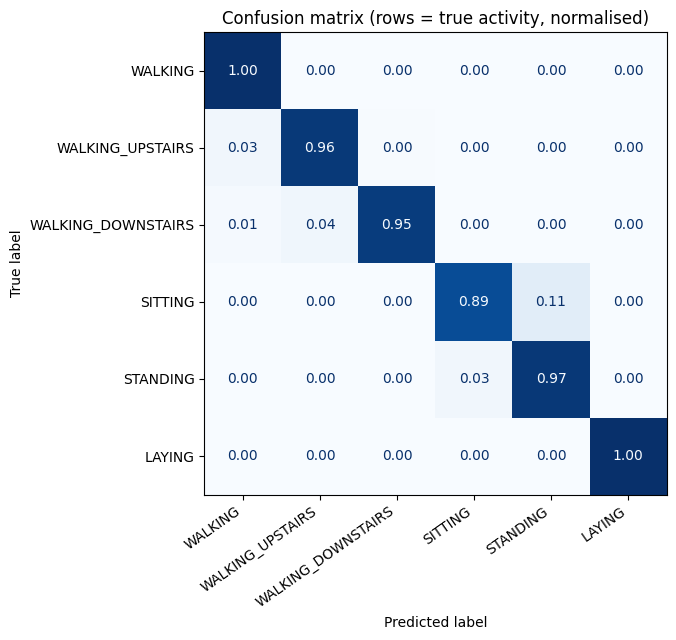

In [17]:
plot_confusion_matrix(y_test, y_pred, ACTIVITIES, config.FIGURES_DIR / "confusion_matrix.png")
plt.show()

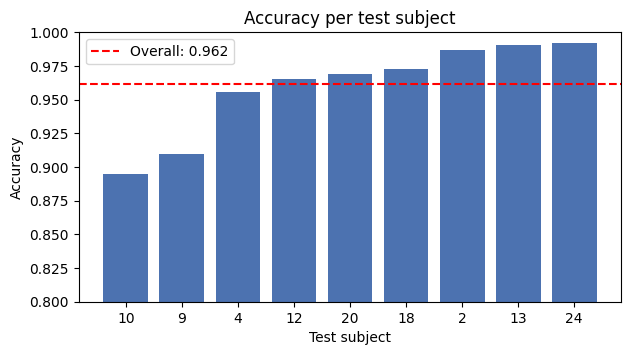

subject,10,9,4,12,20,18,2,13,24
accuracy,0.895,0.91,0.956,0.966,0.969,0.973,0.987,0.991,0.992


In [18]:
subject_acc = per_subject_accuracy(y_test, y_pred, subj_test)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(subject_acc.index.astype(str), subject_acc.values, color="#4c72b0")
ax.axhline(result["accuracy"], color="red", linestyle="--", label=f"Overall: {result['accuracy']:.3f}")
ax.set(ylim=(0.8, 1.0), xlabel="Test subject", ylabel="Accuracy", title="Accuracy per test subject")
ax.legend()
save(fig, "per_subject_accuracy.png")
plt.show()
subject_acc.round(3).to_frame("accuracy").T

**Result on 9 new subjects: accuracy 96.2%, macro-F1 0.962.**
- This is higher than the CV estimate (93.9%). Two reasons: the final model is trained on **all 21** training
  subjects (CV models used only ~17), and the CV standard deviation (±3.4 pp) shows that results depend a lot
  on **which people** are in the test set. The official 9 test subjects seem to be slightly easier than average.
- **Lying is almost perfect** (F1 0.999), and the walking types are all above 0.96.
- **Sitting has the lowest recall (0.888):** 11% of sitting windows are predicted as standing.
- Per-subject accuracy ranges from **89.5% (subject 10) to 99.2% (subject 24)**. For a real product, the
  worst-case person matters as much as the average.

## 9. Error analysis: sitting vs standing

In [19]:
errors = pd.crosstab(pd.Series(y_test.values, name="true"), pd.Series(y_pred, name="predicted"))
errors = errors.stack().rename("count").reset_index()
errors = errors[errors["true"] != errors["predicted"]].sort_values("count", ascending=False)
errors["share_of_all_errors"] = errors["count"] / errors["count"].sum()
errors.head(6).round(3)

,true,predicted,count,share_of_all_errors
8,SITTING,STANDING,53,0.469
13,STANDING,SITTING,18,0.159
33,WALKING_UPSTAIRS,WALKING,16,0.142
29,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS,15,0.133
27,WALKING_DOWNSTAIRS,WALKING,6,0.053
34,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,2,0.018


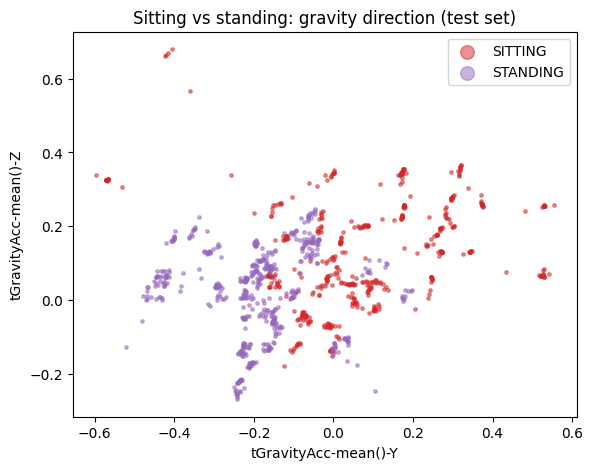

In [20]:
static = y_test.isin(["SITTING", "STANDING"]).to_numpy()
fig, ax = plt.subplots(figsize=(6.5, 5))
for activity in ["SITTING", "STANDING"]:
    mask = (y_test == activity).to_numpy()
    ax.scatter(X_test.loc[mask, "tGravityAcc-mean()-Y"], X_test.loc[mask, "tGravityAcc-mean()-Z"],
               s=6, alpha=0.5, color=COLORS[activity], label=activity)
ax.set(xlabel="tGravityAcc-mean()-Y", ylabel="tGravityAcc-mean()-Z",
       title="Sitting vs standing: gravity direction (test set)")
ax.legend(markerscale=4)
save(fig, "sitting_vs_standing.png")
plt.show()

**Result: 63% of all errors are sitting ↔ standing confusions** (53 sitting → standing, 18 standing → sitting).
The rest are mostly between walking types (upstairs vs level walking).

**Why?** Both activities are static and upright, and the phone is on the **waist**. The only real difference is
a small change in the tilt of the pelvis, visible in the gravity direction. The scatter plot shows that the two
classes overlap, and the overlap is different for each person (the small clumps are individual subjects).

**How to improve:** use **context over time** (a person rarely switches between sitting and standing every
2.5 seconds, so smoothing or a sequence model would fix isolated errors), or add a second sensor position
(e.g. the thigh), where sitting and standing look very different.

## 10. Which sensor signals matter?

Permutation importance by **signal group**: we shuffle all features of one group together
(e.g. all 79 `fBodyAcc` features) and measure the drop in test macro-F1. Shuffling single features
would underestimate importance, because many features are highly correlated.

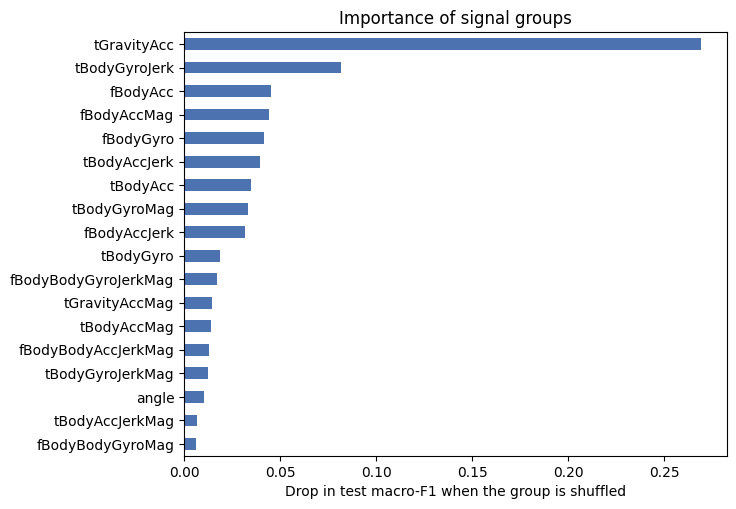

In [21]:
importance = group_permutation_importance(final_model, X_test, y_test, FEATURE_GROUPS,
                                          n_repeats=3, random_state=config.RANDOM_STATE)
fig, ax = plt.subplots(figsize=(7, 5.5))
importance.sort_values().plot.barh(ax=ax, color="#4c72b0")
ax.set(xlabel="Drop in test macro-F1 when the group is shuffled", title="Importance of signal groups")
save(fig, "group_importance.png")
plt.show()

**Result:**
- **`tGravityAcc` is by far the most important group:** shuffling it drops macro-F1 by 0.27. Gravity tells the
  model the **orientation** of the body, which is needed for the static activities (lying vs upright,
  sitting vs standing).
- `tBodyGyroJerk` (how fast the rotation changes) is second. It helps to separate the **walking types**.
- All other groups have a small effect individually, because they carry **overlapping** information: if one
  group is shuffled, the others can compensate.

This is a useful insight for **fall detection**: body orientation relative to gravity (before vs after the
event) and rotation dynamics are exactly the signals that describe a fall.

## 11. Conclusions

| | Result |
|---|---|
| Final model | Linear SVM (C = 0.1) on 561 standardised features |
| Subject-level CV macro-F1 | 0.939 ± 0.035 |
| **Test accuracy / macro-F1 (9 new subjects)** | **96.2% / 0.962** |
| Worst / best test subject | 89.5% / 99.2% |
| Main error | Sitting ↔ standing (63% of all errors) |

**Key takeaways**
1. **Split by subject.** A random split overestimated accuracy by 6–8 percentage points, because windows overlap
   and the model learns each person's movement style.
2. **Simple models can win.** With good engineered features, a linear SVM beat random forests and gradient
   boosting, and it trains in under a second.
3. **The curse of dimensionality depends on the data.** It is dramatic for random dimensions, but these 561
   features are correlated with a low intrinsic dimension (26 components for 80% of the variance), so kNN
   only plateaued instead of failing.
4. **Errors are physically meaningful.** The waist sensor can hardly see the difference between sitting and
   standing; gravity-based orientation is the most important signal.

**Next steps:** learn features directly from the raw signals with a **1D-CNN**, add **temporal smoothing** over
consecutive windows, and test generalisation on a **different dataset or device**.